# 🫀 Workshop: Machine Learning para Diagnóstico de Doenças Cardíacas
## UCI Heart Disease Dataset

**Objetivo:** Explorar dados clínicos de pacientes, entender distribuições, tratar variáveis faltantes e construir modelos de classificação para prever presença de doença cardíaca.

---
**Dataset:** [UCI Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease)  
**Fonte:** Cleveland Clinic Foundation  
**Target:** `num` — 0 = sem doença, 1-4 = graus crescentes de doença


## 📦 0. Instalação e Imports

In [4]:
# Instalação (execute apenas uma vez)
%pip install ucimlrepo scikit-learn xgboost imbalanced-learn matplotlib seaborn pandas numpy

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

   ------------- -------------------------- 1/3 [seaborn]
   ------------- -------------------------- 1/3 [seaborn]
   ------------- -------------------------- 1/3 [seaborn]
   ------------- -------------------------- 1/3 [seaborn]
   -------------------------- ------------- 2/3 [imbalanced-learn]
   -------------------------- ------------- 2/3 [imbalanced-learn]
   -------------------------- ------------- 2/3 [imbalanced-learn]
   -------------------------- ------------- 2/3 [imbalanced-learn]
   -------------------------- ------------- 2/3 [imbalanced-learn]
   -------------------------- ------------- 2/3


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Us

In [5]:
import warnings
warnings.filterwarnings('ignore')

# === Dados ===
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

# === Visualização ===
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# === Pré-processamento ===
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# === Modelos ===
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# === Métricas ===
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)

# === Config visual ===
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE = ['#1a6ea8', '#e84545', '#f4a261', '#2ec4b6', '#6a0572']

print('✅ Imports OK')

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 289.4 kB/s eta 0:00:27
   -- ------------------------------------- 0.5/8.1 MB 289.4 kB/s eta 0:00:27
   -- ------------------------------------- 0.5/8.1 MB 289.4 kB/s eta 0:00:27
   -- ------------------------------------- 0.5/8.1 MB 289.4 kB/s eta 0:00:2


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Imports OK


---
## 📥 1. Carregamento dos Dados

In [ ]:
# Carrega o dataset UCI
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

df = pd.concat([X, y], axis=1)

print(f'Shape do dataset: {df.shape}')
print(f'\nColunas: {df.columns.tolist()}')
print(f'\nValores únicos da target "num": {sorted(df["num"].unique())}')

Shape do dataset: (303, 14)

Colunas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Valores únicos da target "num": [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [ ]:
# Dicionário de variáveis para referência
variaveis = {
    'age'     : 'Idade (anos)',
    'sex'     : 'Sexo (1=M, 0=F)',
    'cp'      : 'Tipo de dor no peito (1-4)',
    'trestbps': 'Pressão arterial em repouso (mm Hg)',
    'chol'    : 'Colesterol sérico (mg/dl)',
    'fbs'     : 'Glicemia em jejum > 120 mg/dl (1=Sim)',
    'restecg' : 'Resultado ECG em repouso (0-2)',
    'thalach' : 'Frequência cardíaca máxima atingida',
    'exang'   : 'Angina induzida por exercício (1=Sim)',
    'oldpeak' : 'Depressão ST induzida por exercício',
    'slope'   : 'Inclinação do segmento ST (1-3)',
    'ca'      : 'Nº de vasos principais (0-3) [FALTANTES]',
    'thal'    : 'Thal: tipo de defeito (3/6/7) [FALTANTES]',
    'num'     : '🎯 TARGET: diagnóstico (0=sem, 1-4=com doença)'
}

desc_df = pd.DataFrame.from_dict(variaveis, orient='index', columns=['Descrição'])
desc_df

,Descrição
age,Idade (anos)
sex,"Sexo (1=M, 0=F)"
cp,Tipo de dor no peito (1-4)
trestbps,Pressão arterial em repouso (mm Hg)
chol,Colesterol sérico (mg/dl)
fbs,Glicemia em jejum > 120 mg/dl (1=Sim)
restecg,Resultado ECG em repouso (0-2)
thalach,Frequência cardíaca máxima atingida
exang,Angina induzida por exercício (1=Sim)
oldpeak,Depressão ST induzida por exercício


In [ ]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


In [ ]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.94
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,1.23
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,2.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,4.00


---
## 🔍 2. Análise de Variáveis Faltantes (Missing Values)

In [ ]:
# === Tabela de missing ===
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('=== Variáveis com dados faltantes ===')
print(missing_df)

=== Variáveis com dados faltantes ===
      Missing Count  Missing %
ca                4       1.32
thal              2       0.66


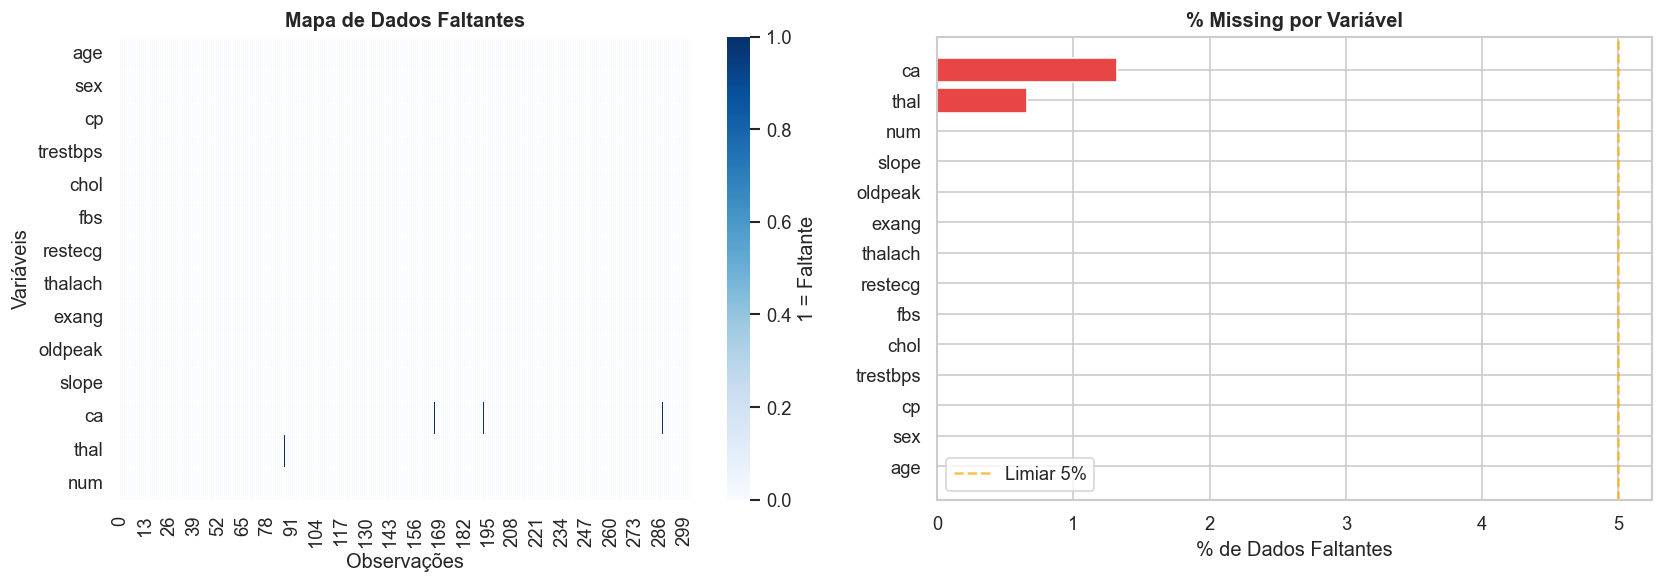


💡 Estratégia de imputação:
  → ca (numérica)  : imputar com a MEDIANA (robusta a outliers)
  → thal (categórica): imputar com a MODA (valor mais frequente)


In [ ]:
# === Heatmap de Missing Values ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
ax = axes[0]
missing_matrix = df.isnull().astype(int)
sns.heatmap(missing_matrix.T, cmap='Blues', ax=ax,
            cbar_kws={'label': '1 = Faltante'},
            linewidths=0.3, linecolor='white')
ax.set_title('Mapa de Dados Faltantes', fontweight='bold')
ax.set_xlabel('Observações')
ax.set_ylabel('Variáveis')

# Barplot de % faltante por coluna
ax2 = axes[1]
all_missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
colors = ['#e84545' if v > 0 else '#1a6ea8' for v in all_missing.values]
ax2.barh(all_missing.index, all_missing.values, color=colors)
ax2.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='Limiar 5%')
ax2.set_xlabel('% de Dados Faltantes')
ax2.set_title('% Missing por Variável', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print('\n💡 Estratégia de imputação:')
print('  → ca (numérica)  : imputar com a MEDIANA (robusta a outliers)')
print('  → thal (categórica): imputar com a MODA (valor mais frequente)')

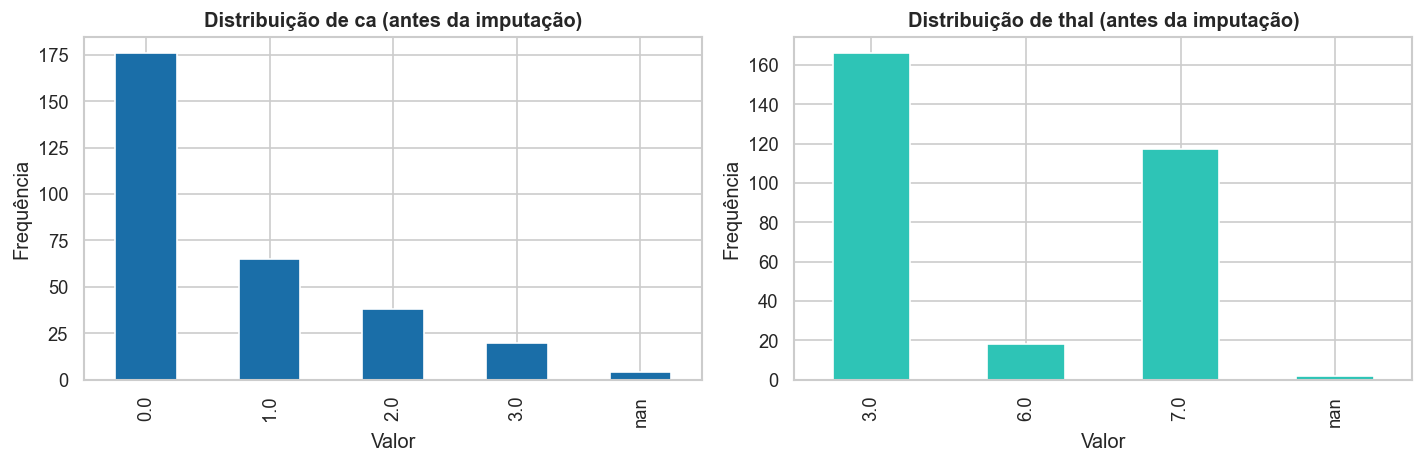

In [ ]:
# === Distribuição das variáveis com missing antes da imputação ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ca
df['ca'].value_counts(dropna=False).sort_index().plot(
    kind='bar', ax=axes[0], color='#1a6ea8', edgecolor='white'
)
axes[0].set_title('Distribuição de ca (antes da imputação)', fontweight='bold')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frequência')

# thal
df['thal'].value_counts(dropna=False).sort_index().plot(
    kind='bar', ax=axes[1], color='#2ec4b6', edgecolor='white'
)
axes[1].set_title('Distribuição de thal (antes da imputação)', fontweight='bold')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

---
## 📊 3. Análise Exploratória (EDA)

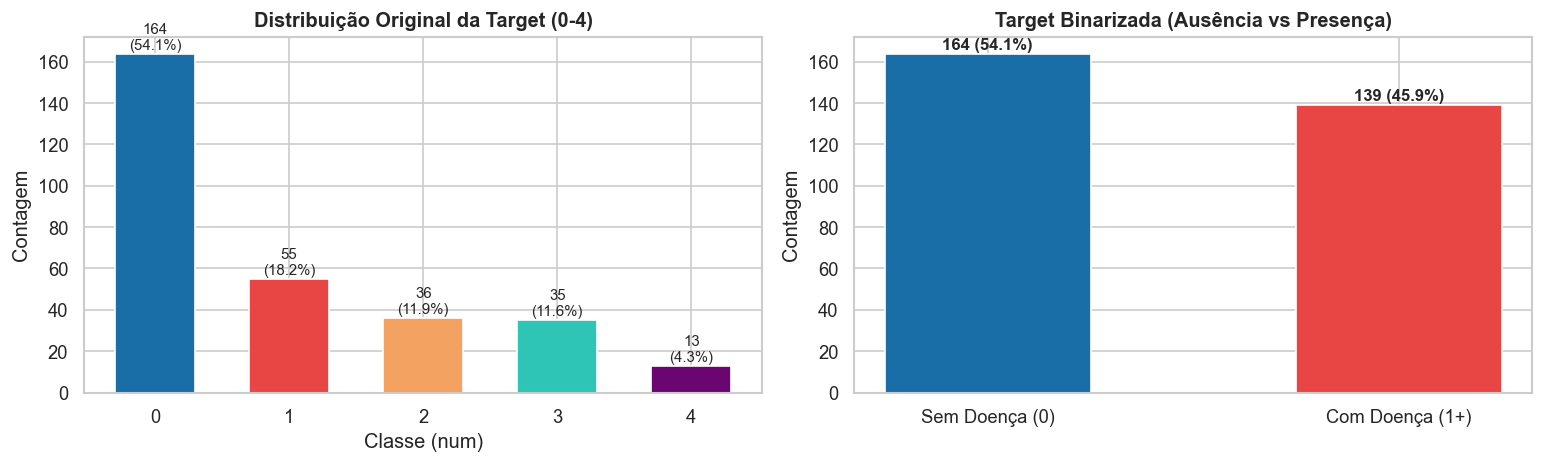


💡 Para modelagem clássica usaremos a versão BINARIZADA: 0 = sem doença, 1 = com doença


In [ ]:
# === Distribuição da Target ===
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Valores originais (0-4)
counts = df['num'].value_counts().sort_index()
bars = axes[0].bar(counts.index.astype(str), counts.values,
                   color=PALETTE, edgecolor='white', width=0.6)
axes[0].set_title('Distribuição Original da Target (0-4)', fontweight='bold')
axes[0].set_xlabel('Classe (num)')
axes[0].set_ylabel('Contagem')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Binária (0 vs 1+)
df['target_bin'] = (df['num'] > 0).astype(int)
bin_counts = df['target_bin'].value_counts().sort_index()
axes[1].bar(['Sem Doença (0)', 'Com Doença (1+)'],
            bin_counts.values,
            color=['#1a6ea8', '#e84545'], edgecolor='white', width=0.5)
axes[1].set_title('Target Binarizada (Ausência vs Presença)', fontweight='bold')
axes[1].set_ylabel('Contagem')
for i, (_, val) in enumerate(bin_counts.items()):
    axes[1].text(i, val + 2, f'{val} ({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n💡 Para modelagem clássica usaremos a versão BINARIZADA: 0 = sem doença, 1 = com doença')

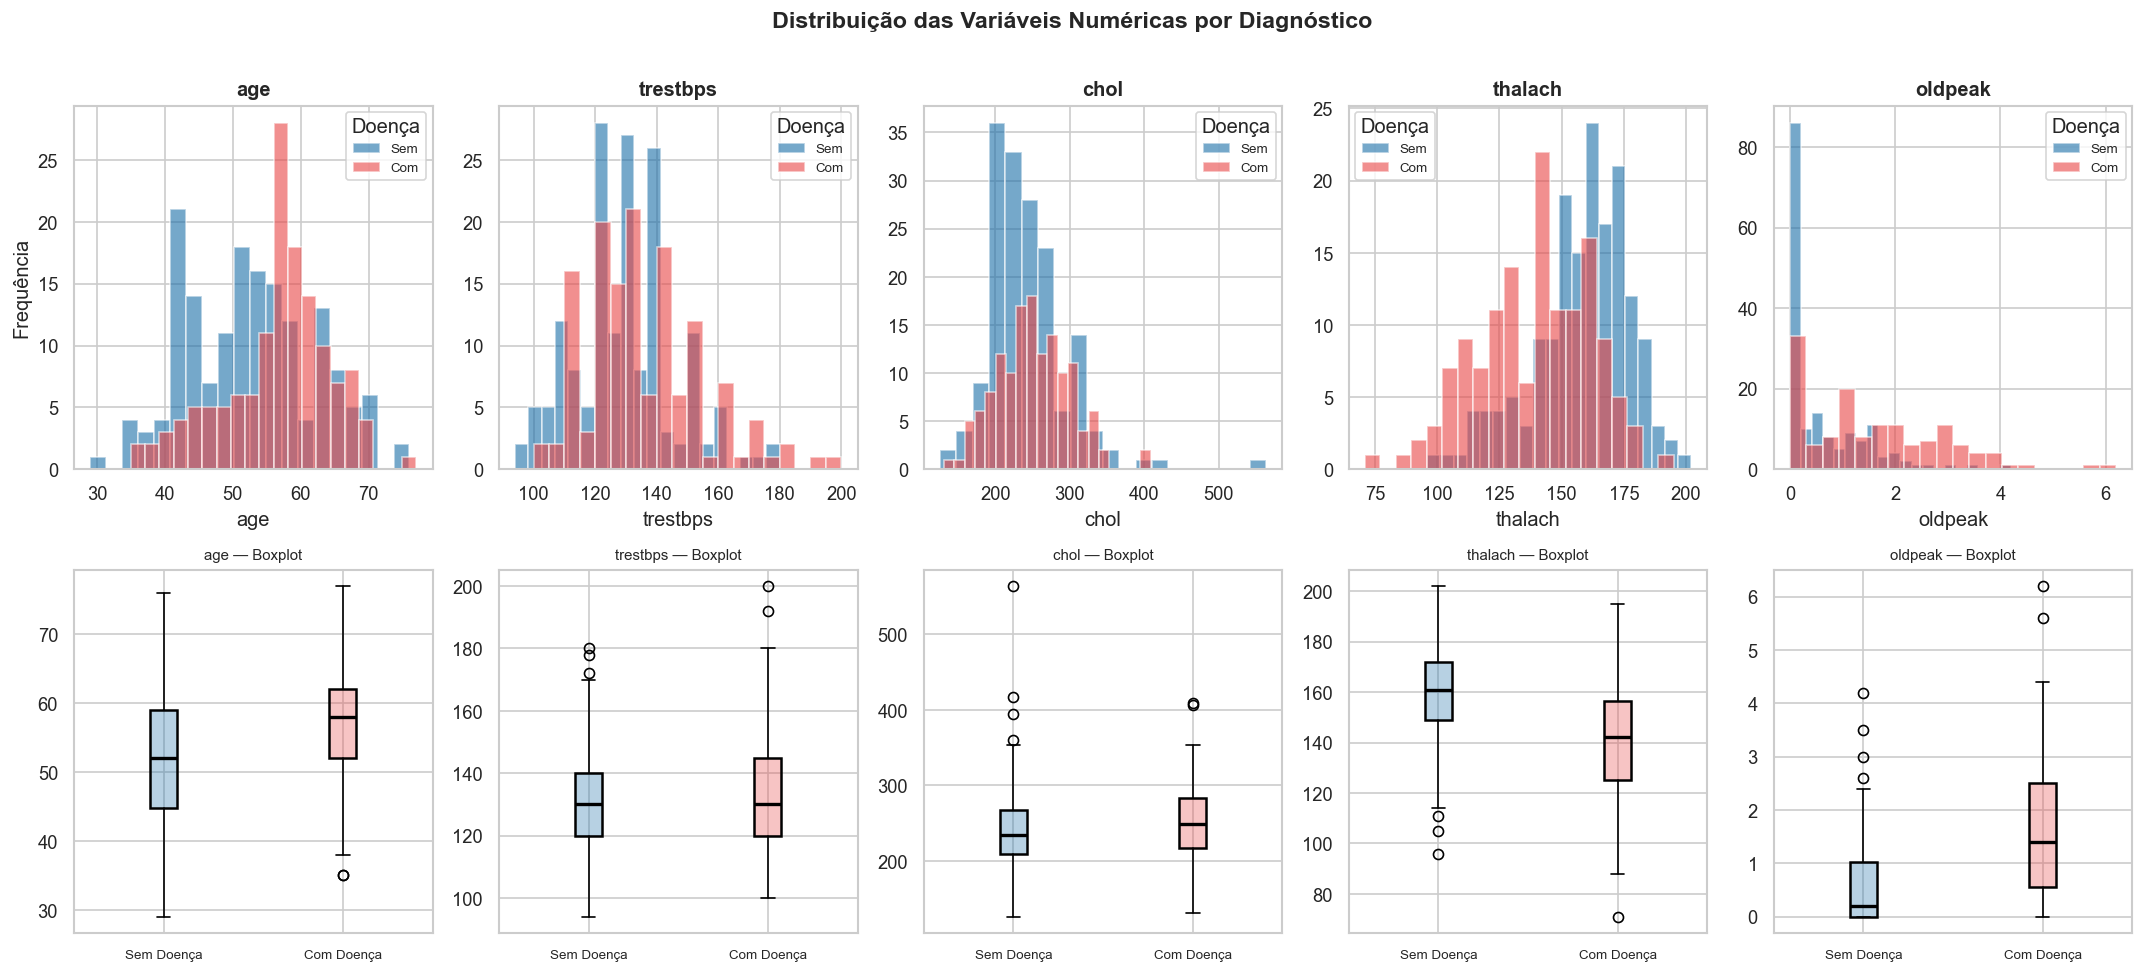

In [ ]:
# === Distribuição das features numéricas ===
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, col in enumerate(num_features):
    # Histograma
    ax = axes[0, i]
    for cls, color in zip([0, 1], ['#1a6ea8', '#e84545']):
        subset = df[df['target_bin'] == cls][col].dropna()
        ax.hist(subset, bins=20, alpha=0.6, color=color,
                label='Sem' if cls == 0 else 'Com',
                edgecolor='white')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel(col)
    if i == 0:
        ax.set_ylabel('Frequência')
    ax.legend(title='Doença', fontsize=8)

    # Boxplot
    ax2 = axes[1, i]
    data_plot = [df[df['target_bin'] == 0][col].dropna(),
                 df[df['target_bin'] == 1][col].dropna()]
    bp = ax2.boxplot(data_plot, patch_artist=True,
                     boxprops=dict(linewidth=1.5),
                     medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#1a6ea850')
    bp['boxes'][1].set_facecolor('#e8454550')
    ax2.set_xticks([1, 2])
    ax2.set_xticklabels(['Sem Doença', 'Com Doença'], fontsize=8)
    ax2.set_title(f'{col} — Boxplot', fontsize=9)

plt.suptitle('Distribuição das Variáveis Numéricas por Diagnóstico',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

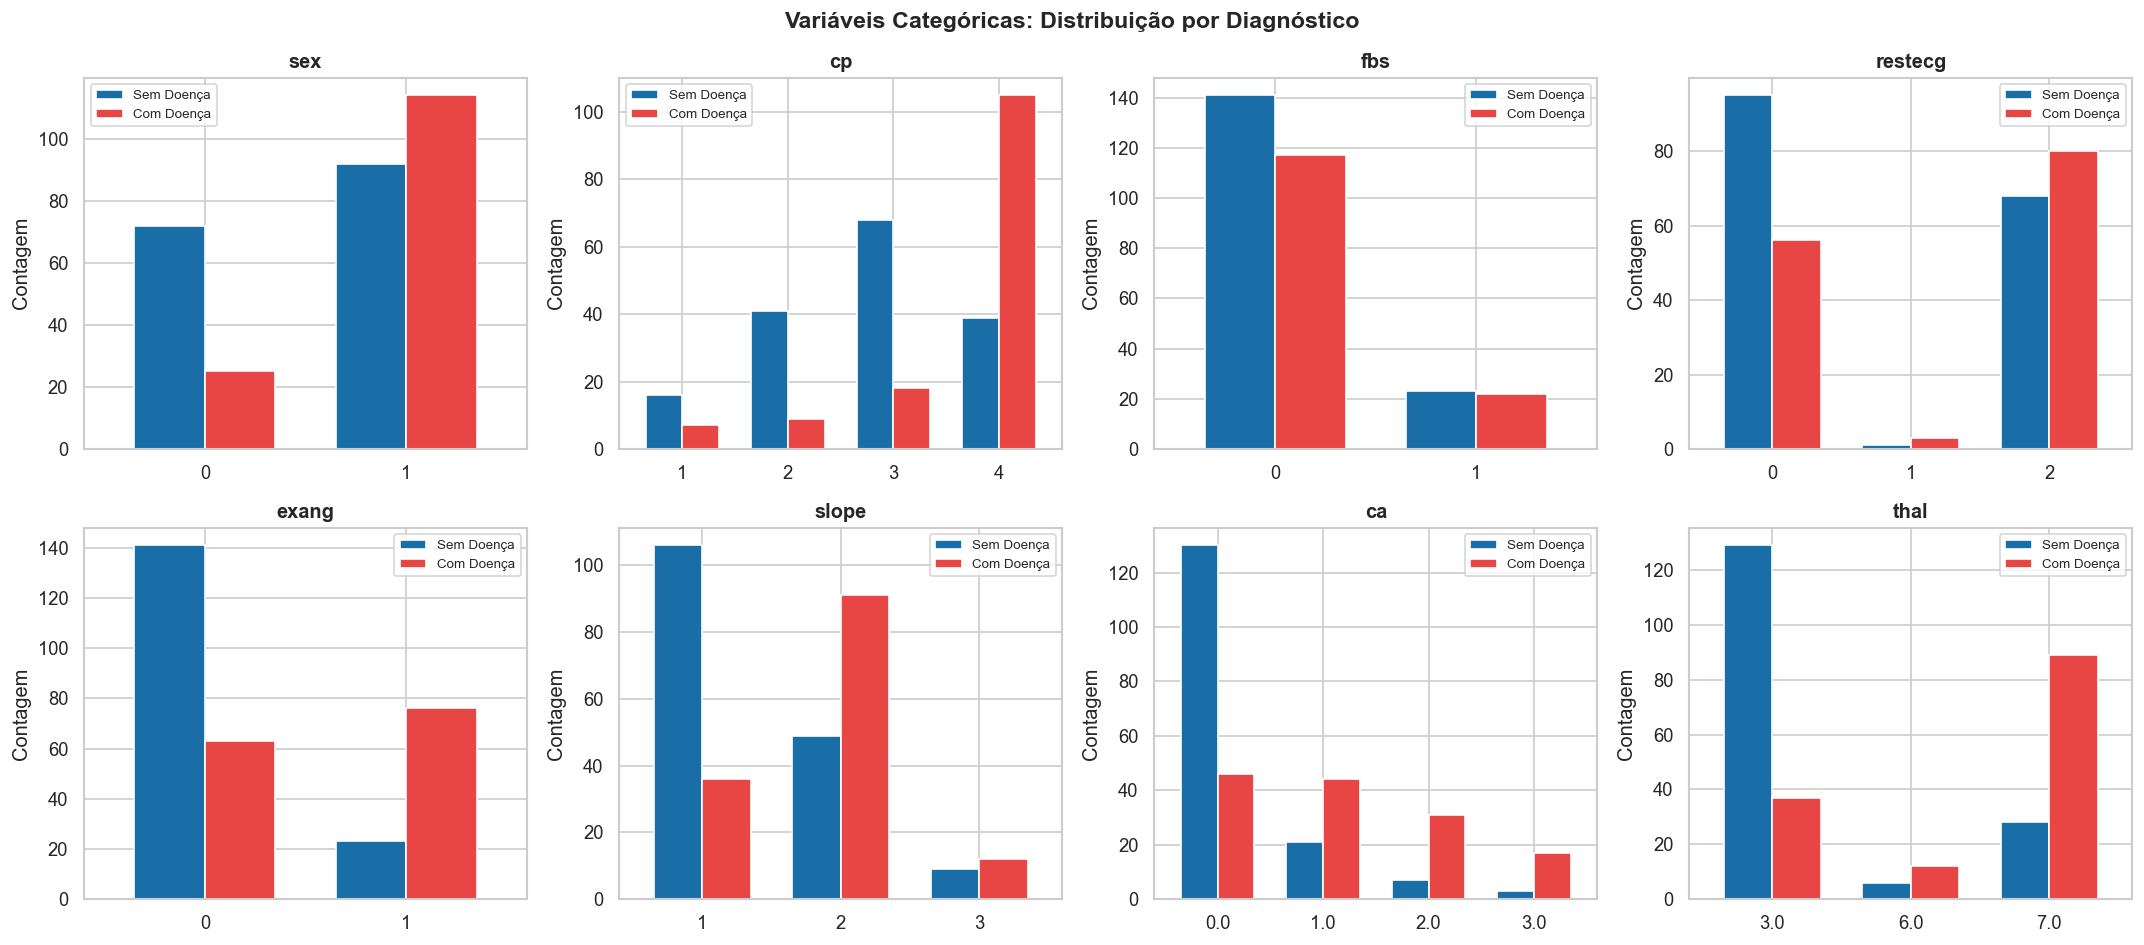

In [ ]:
# === Distribuição das features categóricas ===
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['target_bin'])
    ct.columns = ['Sem Doença', 'Com Doença']
    ct.plot(kind='bar', ax=ax, color=['#1a6ea8', '#e84545'],
            edgecolor='white', width=0.7, rot=0)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Contagem')
    ax.legend(fontsize=8)

plt.suptitle('Variáveis Categóricas: Distribuição por Diagnóstico',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

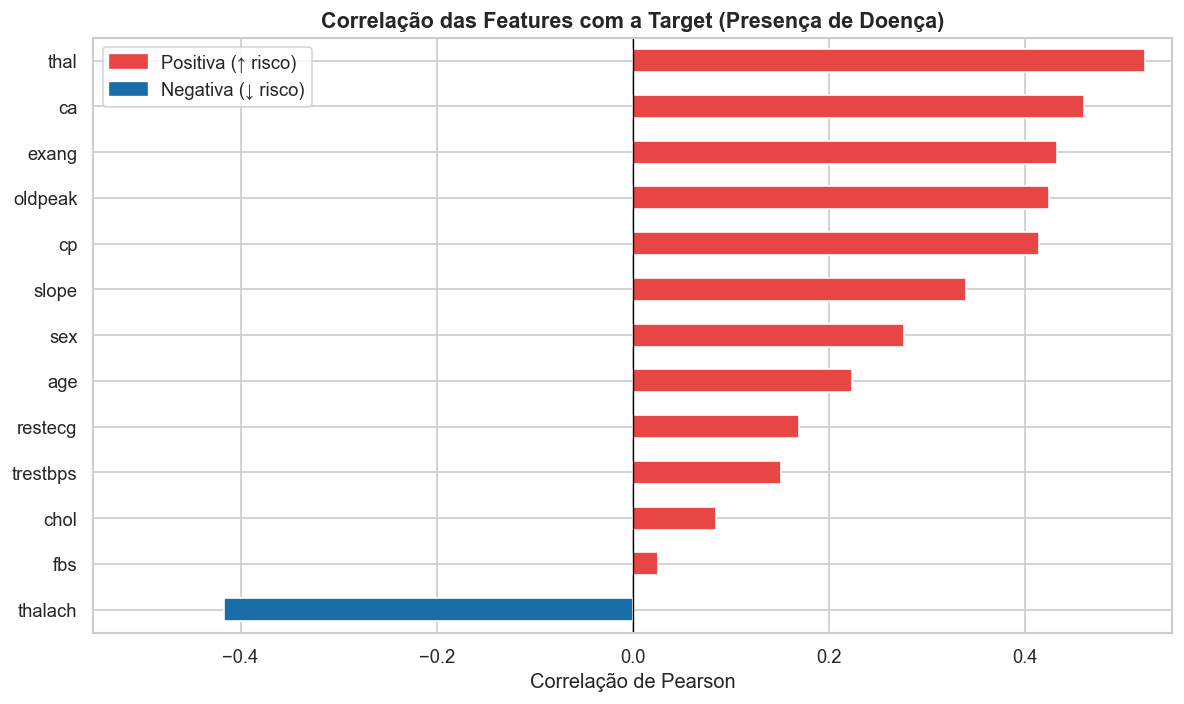

In [ ]:
# === Correlação com a target binarizada ===
fig, ax = plt.subplots(figsize=(10, 6))

df_corr = df.drop(columns=['num']).copy()
# Imputação rápida para correlação
df_corr['ca'] = df_corr['ca'].fillna(df_corr['ca'].median())
df_corr['thal'] = df_corr['thal'].fillna(df_corr['thal'].mode()[0])

corr_target = df_corr.corr()['target_bin'].drop('target_bin').sort_values()
colors = ['#e84545' if c > 0 else '#1a6ea8' for c in corr_target.values]
corr_target.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação das Features com a Target (Presença de Doença)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Correlação de Pearson')
ax.set_xlim(-0.55, 0.55)

red_patch = mpatches.Patch(color='#e84545', label='Positiva (↑ risco)')
blue_patch = mpatches.Patch(color='#1a6ea8', label='Negativa (↓ risco)')
ax.legend(handles=[red_patch, blue_patch])

plt.tight_layout()
plt.show()

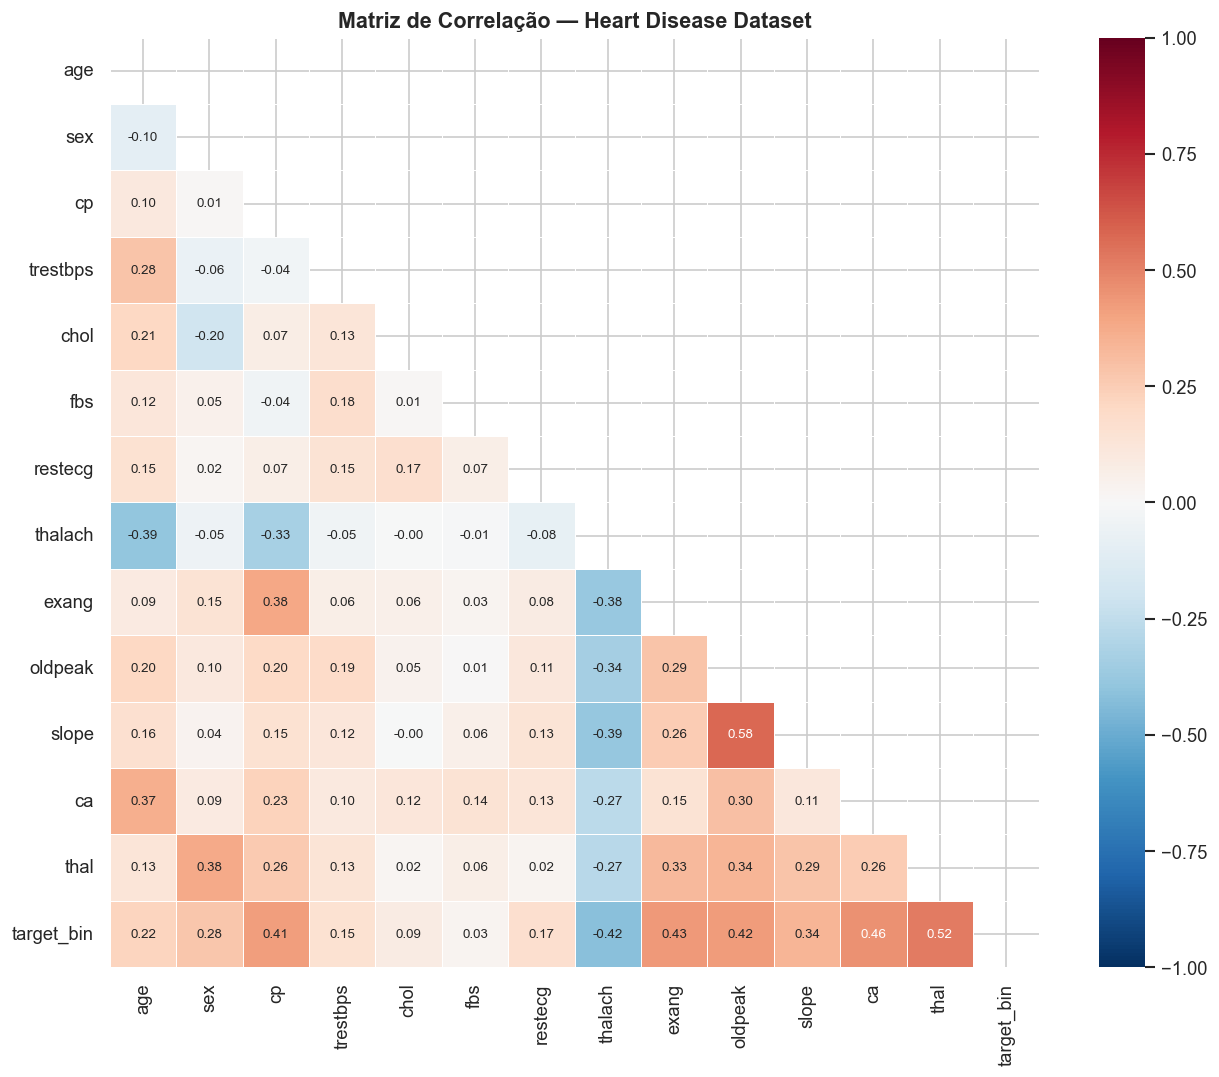

In [ ]:
# === Matriz de Correlação entre todas as features ===
fig, ax = plt.subplots(figsize=(11, 9))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matriz de Correlação — Heart Disease Dataset',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 🛠️ 4. Pré-processamento

In [ ]:
# === Preparação do dataset final ===

# Features e target binarizada
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

X_raw = df[feature_cols].copy()
y_bin = df['target_bin'].copy()

# Imputação manual transparente
X_raw['ca']   = X_raw['ca'].fillna(X_raw['ca'].median())
X_raw['thal'] = X_raw['thal'].fillna(X_raw['thal'].mode()[0])

print('Missing após imputação:')
print(X_raw.isnull().sum())
print(f'\nShape final: X={X_raw.shape}, y={y_bin.shape}')
print(f'\nBalanceamento da target:\n{y_bin.value_counts()}')

Missing após imputação:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

Shape final: X=(303, 13), y=(303,)

Balanceamento da target:
target_bin
0    164
1    139
Name: count, dtype: int64


In [ ]:
# === Train/Test Split (Stratified) ===
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin  # mantém proporção das classes
)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')
print(f'\nProporção treino: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Proporção teste:  {y_test.value_counts(normalize=True).round(3).to_dict()}')

Treino: 242 amostras
Teste:  61 amostras

Proporção treino: {0: 0.541, 1: 0.459}
Proporção teste:  {0: 0.541, 1: 0.459}


In [ ]:
# === Normalização via StandardScaler ===
# (embutido nos pipelines abaixo — boas práticas!)

print('💡 Conceito: StandardScaler')
print('   z = (x - μ) / σ')
print('   Média=0, Desvio Padrão=1')
print('   Essencial para SVM, Regressão Logística e Redes Neurais')
print('   Não necessário para tree-based: RF, XGBoost')

💡 Conceito: StandardScaler
   z = (x - μ) / σ
   Média=0, Desvio Padrão=1
   Essencial para SVM, Regressão Logística e Redes Neurais
   Não necessário para tree-based: RF, XGBoost


---
## 🤖 5. Modelagem — Definição dos Pipelines

Cada modelo é encapsulado em um `Pipeline` do scikit-learn:  
**Scaler → Modelo**  
Isso garante que a normalização é feita corretamente (fit no treino, transform no teste).

In [ ]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Support Vector': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),  # opcional para RF, mas mantemos padrão
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'Neural Network': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                              random_state=42, early_stopping=True))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(n_estimators=100, eval_metric='logloss',
                              random_state=42, verbosity=0))
    ])
}

print('✅ Modelos definidos:', list(models.keys()))

✅ Modelos definidos: ['Logistic Regression', 'Support Vector', 'Random Forest', 'Neural Network', 'XGBoost']


---
## 📈 6. Cross-Validation Baseline (5-Fold Stratified)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, pipeline in models.items():
    print(f'{"-"*50}\nIniciando cross-validation para: {name}')
    scores_acc = cross_val_score(pipeline, X_raw, y_bin, cv=cv,
                                 scoring='accuracy', n_jobs=-1)
    scores_pre = cross_val_score(pipeline, X_raw, y_bin, cv=cv,
                                 scoring='precision', n_jobs=-1)
    cv_results[name] = {
        'Accuracy Mean': scores_acc.mean(),
        'Accuracy Std':  scores_acc.std(),
        'Accuracy Min':  scores_acc.min(),
        'Accuracy Max':  scores_acc.max(),
        'Precision Mean': scores_pre.mean(),
        'Precision Std':  scores_pre.std(),
    }
    print(f'✓ {name}: Acc={scores_acc.mean():.3f} ± {scores_acc.std():.3f}')
    print(f'✓ {name}: Pre={scores_pre.mean():.3f} ± {scores_pre.std():.3f}')


cv_df = pd.DataFrame(cv_results).T.round(4)
cv_df

--------------------------------------------------
Iniciando cross-validation para: Logistic Regression
✓ Logistic Regression: Acc=0.832 ± 0.050
✓ Logistic Regression: Pre=0.830 ± 0.064
--------------------------------------------------
Iniciando cross-validation para: Support Vector
✓ Support Vector: Acc=0.838 ± 0.039
✓ Support Vector: Pre=0.853 ± 0.049
--------------------------------------------------
Iniciando cross-validation para: Random Forest
✓ Random Forest: Acc=0.845 ± 0.046
✓ Random Forest: Pre=0.862 ± 0.069
--------------------------------------------------
Iniciando cross-validation para: Neural Network
✓ Neural Network: Acc=0.776 ± 0.033
✓ Neural Network: Pre=0.775 ± 0.105
--------------------------------------------------
Iniciando cross-validation para: XGBoost
✓ XGBoost: Acc=0.815 ± 0.026
✓ XGBoost: Pre=0.812 ± 0.058


,Accuracy Mean,Accuracy Std,Accuracy Min,Accuracy Max,Precision Mean,Precision Std
Logistic Regression,0.8316,0.0496,0.7833,0.9180,0.8304,0.0643
Support Vector,0.8381,0.0390,0.7833,0.9016,0.8526,0.0488
Random Forest,0.8447,0.0456,0.7833,0.9016,0.8622,0.0695
Neural Network,0.7757,0.0332,0.7213,0.8167,0.7752,0.1049
XGBoost,0.8152,0.0264,0.7833,0.8500,0.8116,0.0583


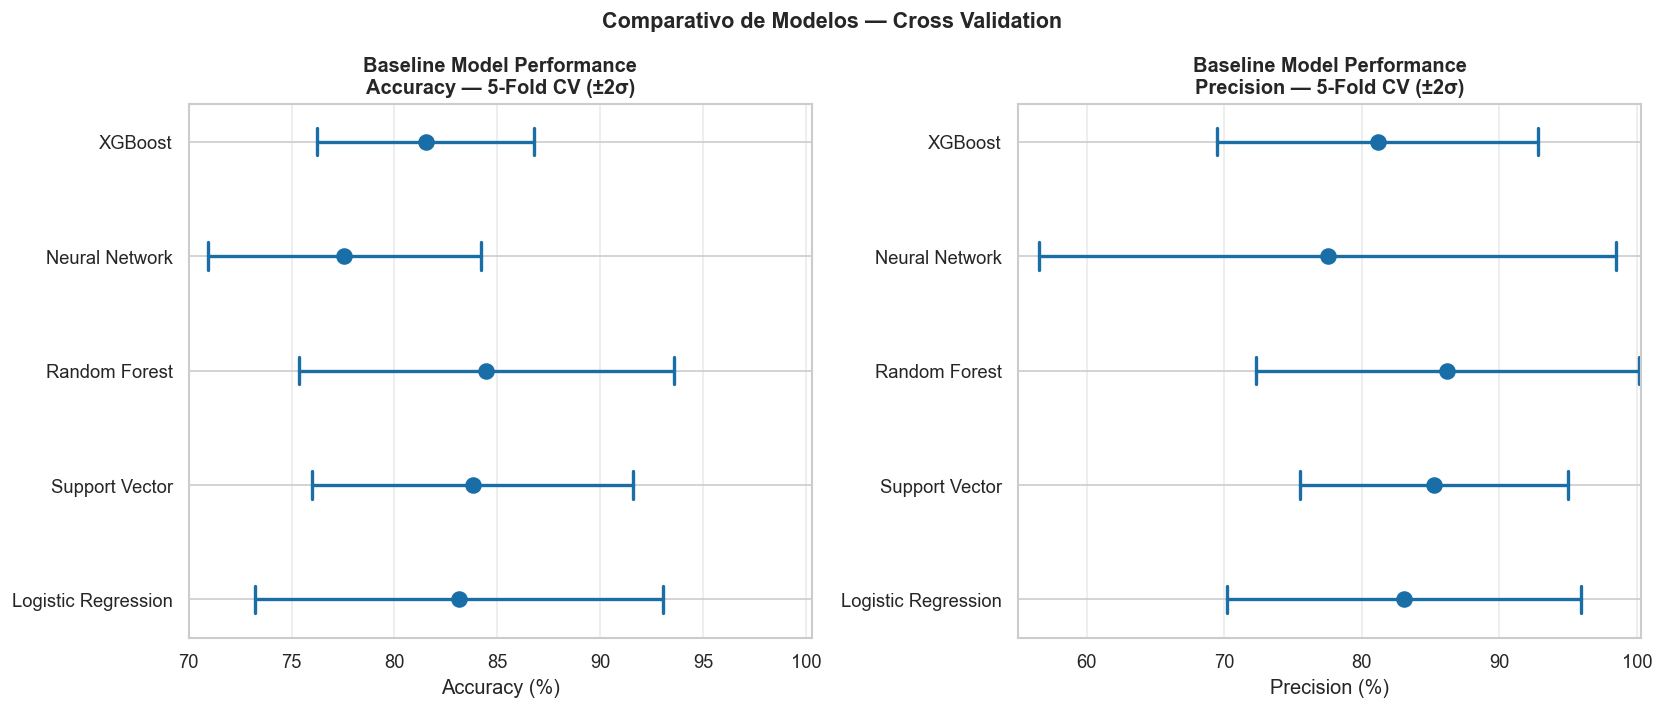

In [ ]:
# === Gráfico tipo Dot Plot (replicando o visual do workshop) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
metrics_plot = [
    ('Accuracy', 'Accuracy Mean', 'Accuracy Std', 'Accuracy Min', 'Accuracy Max'),
    ('Precision', 'Precision Mean', 'Precision Std', None, None)
]

xlim_map = {'Accuracy': (70, 100.3), 'Precision': (55, 100.3)}

for ax, (metric, mean_col, std_col, min_col, max_col) in zip(axes, metrics_plot):
    model_names = cv_df.index.tolist()
    means  = cv_df[mean_col].values * 100
    stds   = cv_df[std_col].values * 100

    for i, (name, mean, std) in enumerate(zip(model_names, means, stds)):
        ax.plot([mean - 2*std, mean + 2*std], [i, i],
                color='#1a6ea8', linewidth=2)
        ax.plot([mean - 2*std, mean - 2*std], [i-0.12, i+0.12],
                color='#1a6ea8', linewidth=2)
        ax.plot([mean + 2*std, mean + 2*std], [i-0.12, i+0.12],
                color='#1a6ea8', linewidth=2)
        ax.scatter(mean, i, color='#1a6ea8', s=80, zorder=5)

    ax.set_yticks(range(len(model_names)))
    ax.set_yticklabels(model_names)
    ax.set_xlim(*xlim_map[metric])
    ax.set_xlabel(f'{metric} (%)')
    ax.set_title(f'Baseline Model Performance\n{metric} — 5-Fold CV (±2σ)',
                 fontweight='bold')
    ax.grid(axis='x', alpha=0.4)

plt.suptitle('Comparativo de Modelos — Cross Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔬 7. Treinamento Final e Métricas no Conjunto de Teste

In [ ]:
# Treina todos os modelos no conjunto de treino e avalia no teste
results = {}
predictions = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    }

results_df = pd.DataFrame(results).T.round(4)
print('=== Métricas no conjunto de teste ===')
results_df

=== Métricas no conjunto de teste ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
Support Vector,0.8525,0.8065,0.8929,0.8475,0.9437
Random Forest,0.8852,0.8182,0.9643,0.8852,0.9513
Neural Network,0.8525,0.8065,0.8929,0.8475,0.9318
XGBoost,0.8525,0.7879,0.9286,0.8525,0.9188


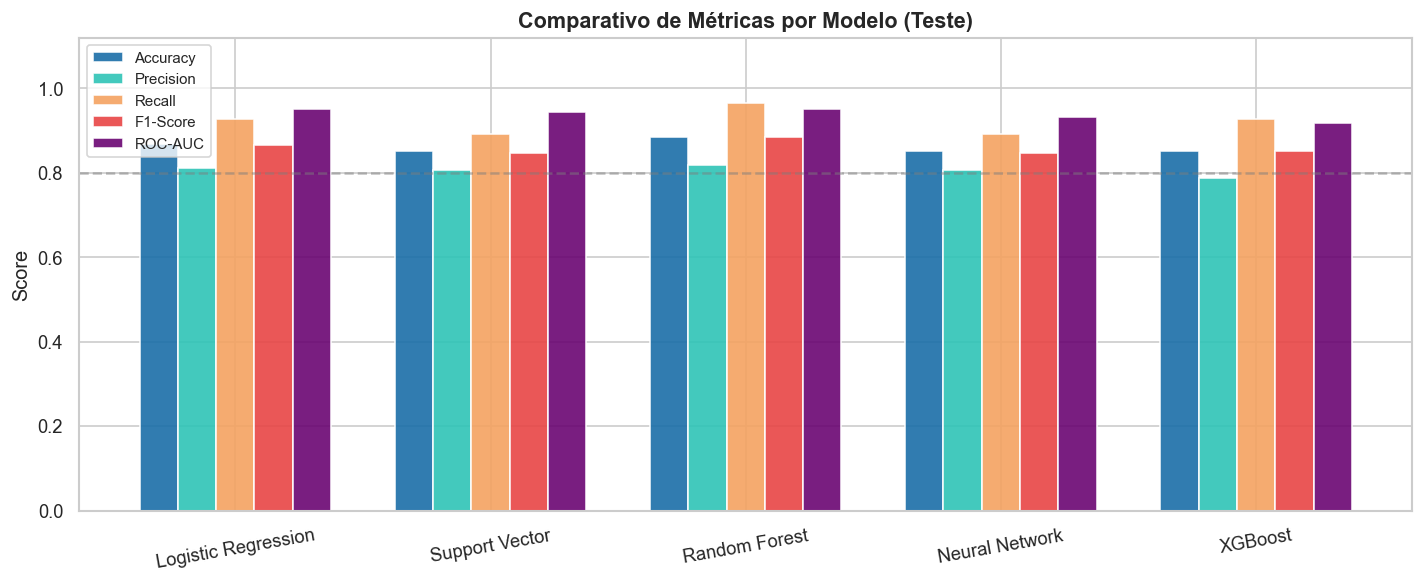

In [ ]:
# === Gráfico de métricas comparativas ===
fig, ax = plt.subplots(figsize=(12, 5))

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(results_df.index))
width = 0.15
bar_colors = ['#1a6ea8', '#2ec4b6', '#f4a261', '#e84545', '#6a0572']

for i, (metric, color) in enumerate(zip(metric_cols, bar_colors)):
    bars = ax.bar(x + i*width, results_df[metric], width,
                  label=metric, color=color, edgecolor='white', alpha=0.9)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Comparativo de Métricas por Modelo (Teste)', fontweight='bold', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Limiar 0.8')

plt.tight_layout()
plt.show()

---
## 📉 8. Curva ROC-AUC — Comparativo dos Modelos

A **curva ROC** (Receiver Operating Characteristic) plota a **Taxa de Verdadeiro Positivo (TPR/Recall)**  
contra a **Taxa de Falso Positivo (FPR)** em todos os limiares de decisão possíveis.

- **AUC = 1.0** → modelo perfeito  
- **AUC = 0.5** → modelo aleatório (linha diagonal)  
- **AUC > 0.8** → geralmente considerado bom para uso clínico

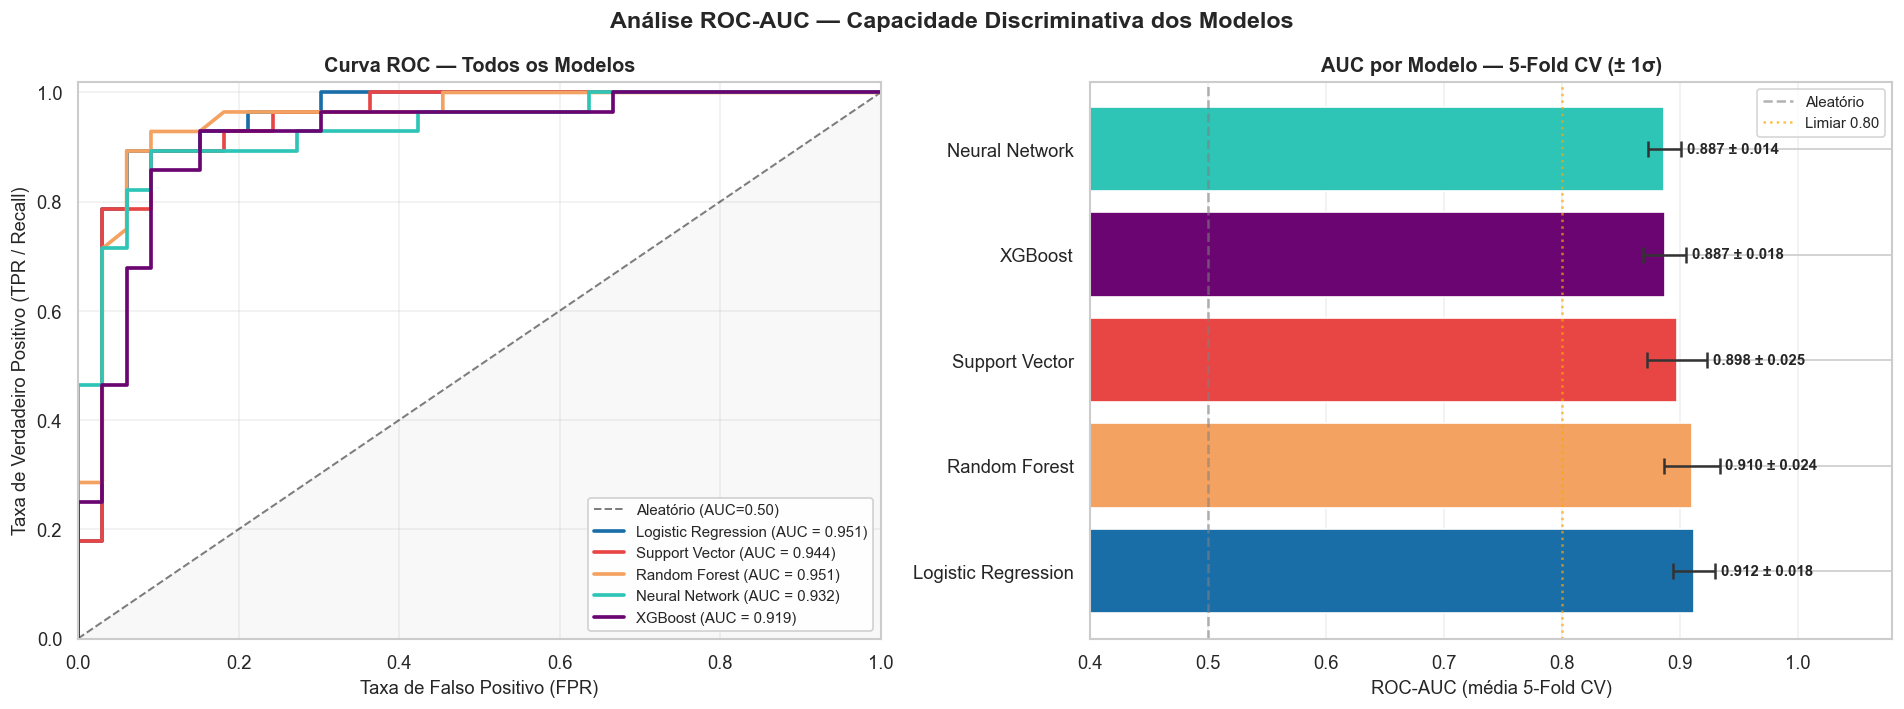


💡 Interpretação:
   AUC mede a probabilidade do modelo rankear um caso positivo ACIMA de um negativo.
   É independente do limiar de decisão → ideal para comparação entre modelos.


In [ ]:
from sklearn.metrics import roc_curve, auc

# === Curva ROC comparativa ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

roc_colors = ['#1a6ea8', '#e84545', '#f4a261', '#2ec4b6', '#6a0572']

# --- Painel esquerdo: todas as curvas sobrepostas ---
ax_left = axes[0]
ax_left.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.5, label='Aleatório (AUC=0.50)')

for (name, pipeline), color in zip(models.items(), roc_colors):
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax_left.plot(fpr, tpr, color=color, linewidth=2.2,
                 label=f'{name} (AUC = {roc_auc:.3f})')

ax_left.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax_left.set_xlim([0.0, 1.0])
ax_left.set_ylim([0.0, 1.02])
ax_left.set_xlabel('Taxa de Falso Positivo (FPR)', fontsize=11)
ax_left.set_ylabel('Taxa de Verdadeiro Positivo (TPR / Recall)', fontsize=11)
ax_left.set_title('Curva ROC — Todos os Modelos', fontweight='bold', fontsize=12)
ax_left.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax_left.grid(alpha=0.3)

# --- Painel direito: barplot de AUC com IC de CV ---
ax_right = axes[1]

cv_auc_results = {}
for name, pipeline in models.items():
    scores_auc = cross_val_score(pipeline, X_raw, y_bin, cv=cv,
                                 scoring='roc_auc', n_jobs=-1)
    cv_auc_results[name] = scores_auc

names_list  = list(cv_auc_results.keys())
means_auc   = [v.mean() for v in cv_auc_results.values()]
stds_auc    = [v.std()  for v in cv_auc_results.values()]

sorted_idx = np.argsort(means_auc)[::-1]
names_sorted = [names_list[i] for i in sorted_idx]
means_sorted = [means_auc[i]  for i in sorted_idx]
stds_sorted  = [stds_auc[i]   for i in sorted_idx]
colors_sorted = [roc_colors[i] for i in sorted_idx]

bars = ax_right.barh(names_sorted, means_sorted, xerr=stds_sorted,
                     color=colors_sorted, edgecolor='white',
                     error_kw=dict(ecolor='#333333', lw=1.5, capsize=5, capthick=1.5))

for bar, mean, std in zip(bars, means_sorted, stds_sorted):
    ax_right.text(mean + std + 0.005, bar.get_y() + bar.get_height()/2,
                  f'{mean:.3f} ± {std:.3f}',
                  va='center', fontsize=9, fontweight='bold')

ax_right.axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='Aleatório')
ax_right.axvline(0.8, color='orange', linestyle=':', alpha=0.7, label='Limiar 0.80')
ax_right.set_xlim(0.4, 1.08)
ax_right.set_xlabel('ROC-AUC (média 5-Fold CV)', fontsize=11)
ax_right.set_title('AUC por Modelo — 5-Fold CV (± 1σ)', fontweight='bold', fontsize=12)
ax_right.legend(fontsize=9)
ax_right.grid(axis='x', alpha=0.3)

plt.suptitle('Análise ROC-AUC — Capacidade Discriminativa dos Modelos',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Interpretação:')
print('   AUC mede a probabilidade do modelo rankear um caso positivo ACIMA de um negativo.')
print('   É independente do limiar de decisão → ideal para comparação entre modelos.')

---
## 🧩 9. Matrizes de Confusão

In [ ]:
# === Conceito — Matriz de Confusão ===
print('''
╔══════════════════════════════════════════════════════════════════╗
║               CONCEITO: Matriz de Confusão                       ║
╠══════════════════════════════════════════════════════════════════╣
║                  Previsto: Negativo  |  Previsto: Positivo        ║
║  Real: Negativo      TN (✅)         |      FP (❌) Tipo I        ║
║  Real: Positivo      FN (❌) Tipo II |      TP (✅)               ║
╠══════════════════════════════════════════════════════════════════╣
║  Accuracy  = (TP + TN) / Total                                    ║
║  Precision = TP / (TP + FP)  → "Dos que previ como doente..."     ║
║  Recall    = TP / (TP + FN)  → "Dos que eram doentes..."          ║
║  F1-Score  = 2 × (Prec × Rec) / (Prec + Rec)                    ║
╚══════════════════════════════════════════════════════════════════╝

⚠️  Em diagnóstico médico: minimizar FALSOS NEGATIVOS (FN) é crítico!
    Um FN = paciente com doença diagnosticado como saudável.
    → Recall alto é mais importante que Precision neste contexto.
''')


╔══════════════════════════════════════════════════════════════════╗
║               CONCEITO: Matriz de Confusão                       ║
╠══════════════════════════════════════════════════════════════════╣
║                  Previsto: Negativo  |  Previsto: Positivo        ║
║  Real: Negativo      TN (✅)         |      FP (❌) Tipo I        ║
║  Real: Positivo      FN (❌) Tipo II |      TP (✅)               ║
╠══════════════════════════════════════════════════════════════════╣
║  Accuracy  = (TP + TN) / Total                                    ║
║  Precision = TP / (TP + FP)  → "Dos que previ como doente..."     ║
║  Recall    = TP / (TP + FN)  → "Dos que eram doentes..."          ║
║  F1-Score  = 2 × (Prec × Rec) / (Prec + Rec)                    ║
╚══════════════════════════════════════════════════════════════════╝

⚠️  Em diagnóstico médico: minimizar FALSOS NEGATIVOS (FN) é crítico!
    Um FN = paciente com doença diagnosticado como saudável.
    → Recall alto é mais importante qu

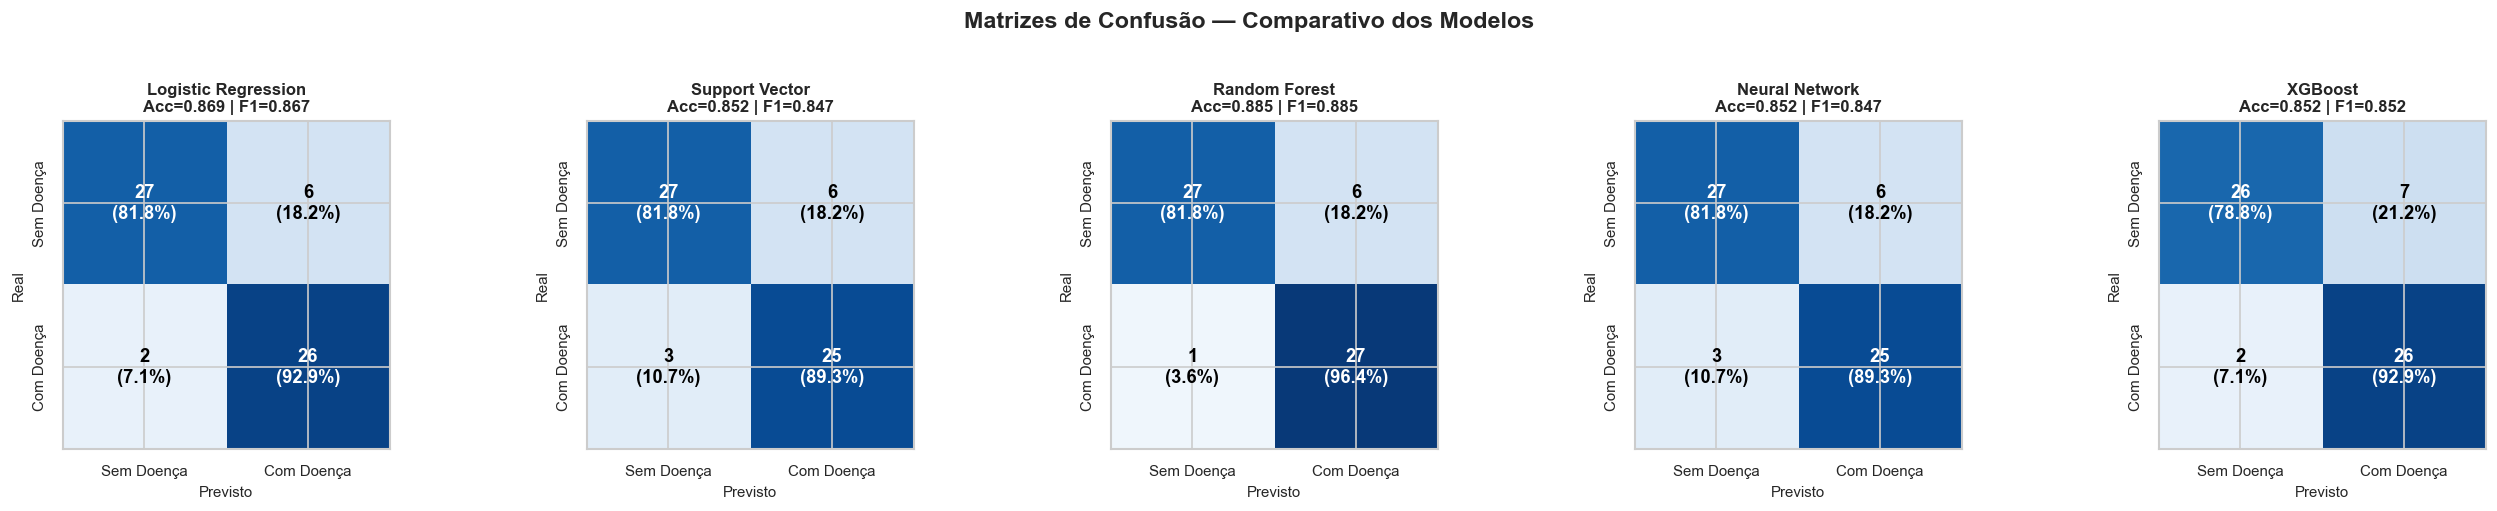

In [ ]:
# === Plot das 5 Matrizes de Confusão ===
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

class_labels = ['Sem Doença', 'Com Doença']

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    # Normalizada (proporção) para o colormap
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)

    # Anotações com valor absoluto e percentual
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text_color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)',
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color=text_color)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_labels, fontsize=9)
    ax.set_yticklabels(class_labels, fontsize=9, rotation=90, va='center')
    ax.set_xlabel('Previsto', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)

    # Métricas no título
    acc = results[name]['Accuracy']
    f1  = results[name]['F1-Score']
    ax.set_title(f'{name}\nAcc={acc:.3f} | F1={f1:.3f}',
                 fontweight='bold', fontsize=10)

plt.suptitle('Matrizes de Confusão — Comparativo dos Modelos',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

In [ ]:
# === Relatório completo por modelo ===
for name, y_pred in predictions.items():
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(y_test, y_pred,
                                 target_names=['Sem Doença', 'Com Doença']))


  Logistic Regression
              precision    recall  f1-score   support

  Sem Doença       0.93      0.82      0.87        33
  Com Doença       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


  Support Vector
              precision    recall  f1-score   support

  Sem Doença       0.90      0.82      0.86        33
  Com Doença       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61


  Random Forest
              precision    recall  f1-score   support

  Sem Doença       0.96      0.82      0.89        33
  Com Doença       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg    

---
## 🌲 10. Feature Importance (Random Forest & XGBoost)

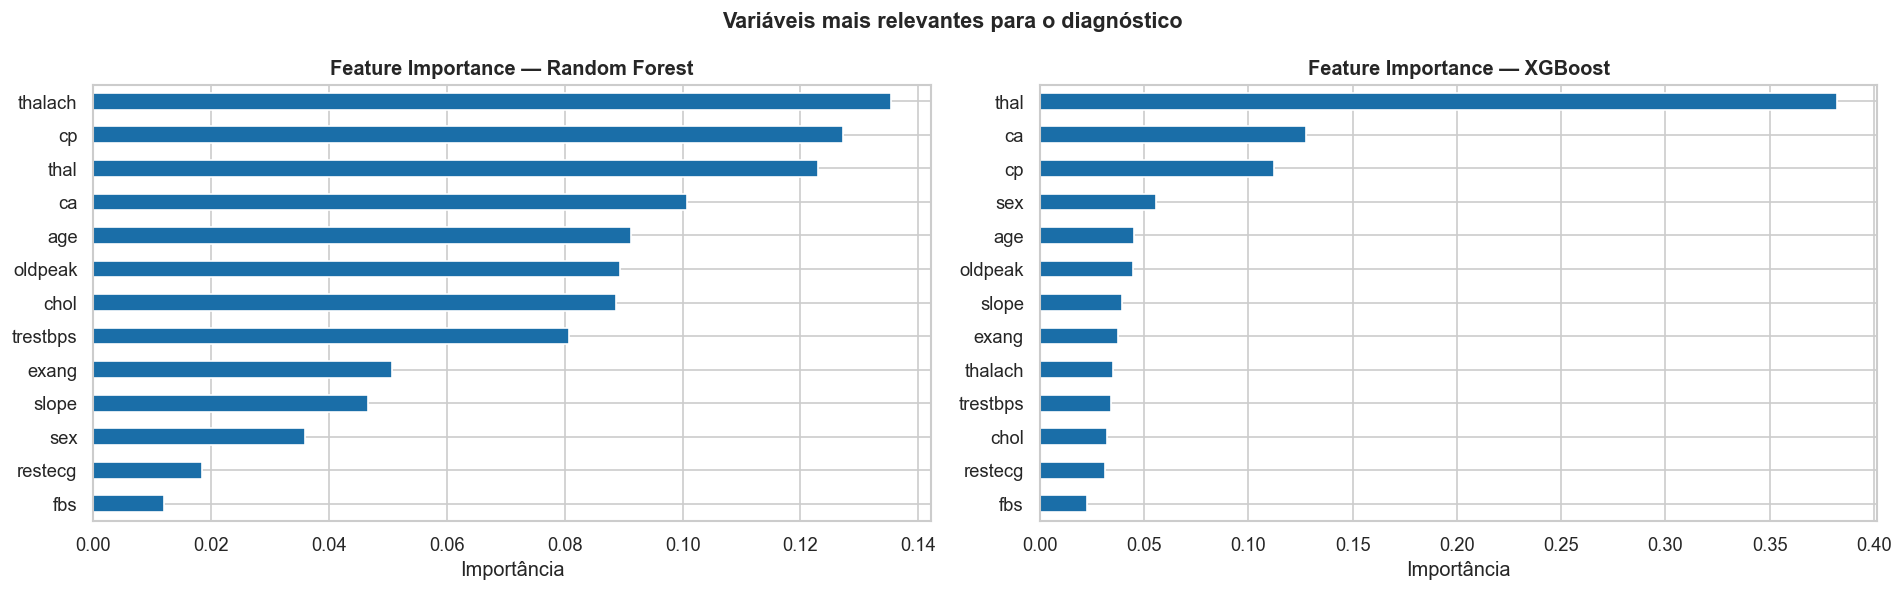

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    clf = models[model_name].named_steps['clf']
    importances = clf.feature_importances_
    fi_df = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

    fi_df.plot(kind='barh', ax=ax, color='#1a6ea8', edgecolor='white')
    ax.set_title(f'Feature Importance — {model_name}', fontweight='bold')
    ax.set_xlabel('Importância')

plt.suptitle('Variáveis mais relevantes para o diagnóstico',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📋 11. Resumo Final

In [ ]:
print('=' * 65)
print('   RESUMO FINAL — PERFORMANCE NOS DADOS DE TESTE')
print('=' * 65)
styled = results_df.sort_values('F1-Score', ascending=False)
print(styled.to_string())
print('=' * 65)
best = styled.index[0]
print(f'\n🏆 Melhor modelo (F1-Score): {best}')
print(f'   Accuracy : {styled.loc[best, "Accuracy"]:.4f}')
print(f'   F1-Score : {styled.loc[best, "F1-Score"]:.4f}')
print(f'   ROC-AUC  : {styled.loc[best, "ROC-AUC"]:.4f}')

print('''
💡 Lições do Workshop:
   1. Imputação de missing deve ser feita APENAS com dados de treino
   2. Pipeline evita data leakage entre treino e teste
   3. Stratified split preserva proporção das classes
   4. Em medicina: Recall > Precision (custo do FN é alto)
   5. Cross-validation > avaliação no hold-out para datasets pequenos
   6. Feature importance ajuda na interpretabilidade do modelo
''')

   RESUMO FINAL — PERFORMANCE NOS DADOS DE TESTE
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest          0.8852     0.8182  0.9643    0.8852   0.9513
Logistic Regression    0.8689     0.8125  0.9286    0.8667   0.9513
XGBoost                0.8525     0.7879  0.9286    0.8525   0.9188
Support Vector         0.8525     0.8065  0.8929    0.8475   0.9437
Neural Network         0.8525     0.8065  0.8929    0.8475   0.9318

🏆 Melhor modelo (F1-Score): Random Forest
   Accuracy : 0.8852
   F1-Score : 0.8852
   ROC-AUC  : 0.9513

💡 Lições do Workshop:
   1. Imputação de missing deve ser feita APENAS com dados de treino
   2. Pipeline evita data leakage entre treino e teste
   3. Stratified split preserva proporção das classes
   4. Em medicina: Recall > Precision (custo do FN é alto)
   5. Cross-validation > avaliação no hold-out para datasets pequenos
   6. Feature importance ajuda na interpretabilidade do modelo



---
## 🚀 Desafios para o Workshop

1. **Multiclasse**: Refaça os modelos com a target original (0-4) — como muda a matriz de confusão?
2. **Hyperparameter Tuning**: Use `GridSearchCV` para otimizar o melhor modelo
3. **Class Weights**: Adicione `class_weight='balanced'` nos modelos — por quê isso importa?
4. **Threshold**: Mude o limiar de decisão de 0.5 para 0.3 — o que acontece com Recall e Precision?
5. **SHAP**: Instale `shap` e interprete as previsões individuais do XGBoost

```python
# Dica para GridSearch:
from sklearn.model_selection import GridSearchCV
param_grid = {'clf__n_estimators': [50, 100, 200], 'clf__max_depth': [3, 5, 7]}
grid = GridSearchCV(models['Random Forest'], param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)
print(grid.best_params_)
```